In [1]:
%cd ..

/home/suetin/Projects/UltrasoundCardiacReconstruction/MAE-Segmentation


/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from src.mae import MAEPretrainer, get_mae_model

/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import yaml

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision.transforms import v2 as T
from torch.utils.data import DataLoader
import glob
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import pytorch_lightning as pl
import random
from PIL import Image

In [5]:
# class EchoVideoFrameDataset(Dataset):
#     def __init__(self, video_paths, batch_size=8, transform=None, frame_skip=1):
#         """
#         Args:
#             video_paths (list): paths to .avi files
#             batch_size (int): number of frames to return per sample
#             transform (callable): transform to apply to each frame
#             frame_skip (int): sample every N-th frame to reduce redundancy
#         """
#         self.video_paths = video_paths
#         self.batch_size = batch_size
#         self.transform = transform
#         self.frame_skip = frame_skip

#     def __len__(self):
#         return len(self.video_paths)

#     def __getitem__(self, idx):
#         path = self.video_paths[idx]
#         frames = self._load_frames(path)

#         if len(frames) == 0:
#             raise RuntimeError(f"No frames found in {path}")

#         # Randomly sample batch_size frames (with replacement if needed)
#         indices = np.random.choice(len(frames), self.batch_size, replace=(len(frames) < self.batch_size))
#         selected = [frames[i] for i in indices]

#         # Apply transforms
#         selected = [self.transform(frame) for frame in selected]  # each → (C,H,W)
#         batch = torch.stack(selected, dim=0)  # (B,C,H,W)
#         return {"pixel_values": batch}

#     def _load_frames(self, path):
#         cap = cv2.VideoCapture(path)
#         if not cap.isOpened():
#             raise IOError(f"Cannot open video {path}")

#         frames = []
#         frame_idx = 0
#         while True:
#             ret, frame = cap.read()
#             if not ret:
#                 break
#             if frame_idx % self.frame_skip == 0:
#                 frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                 frame = Image.fromarray(frame)
#                 frames.append(frame)
#             frame_idx += 1
#         cap.release()
#         return frames

In [6]:


# video_dir = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/raw/EchoNet-Dynamic/Videos"
# video_paths = glob.glob(os.path.join(video_dir, "*.avi"))

# transform = T.Compose([
#     T.Resize((224, 224)),
#     T.ToTensor(),  # if using torchvision v2
#     # T.ConvertImageDtype(torch.float32),
#     T.Normalize([0.5], [0.5])  # for grayscale
# ])

# dataset = EchoVideoFrameDataset(video_paths, batch_size=32, transform=transform)
# loader = DataLoader(dataset, 
#                     batch_size=1, # Batch size 1 due to we use a video
#                     shuffle=True, 
#                     num_workers=4, 
#                     collate_fn=lambda x: x[0])  # Collate function to handle single video) 

# # # In training loop:
# # for batch in loader:
# #     imgs = batch["pixel_values"]  # shape (1, B, C, H, W)
# #     imgs = imgs.squeeze(0)        # shape (B, C, H, W) for MAE input


In [7]:
# batch = next(iter(loader))
# print(batch["pixel_values"].shape)  # should be (1, B, C, H, W)

In [8]:
# torch.cuda.empty_cache()
# torch.cuda.is_available()

In [9]:
# model = MAEPretrainer(cfg)

# trainer = pl.Trainer(
#     max_epochs=cfg['epochs'],
#     precision=16,        # mixed precision for speed
#     accelerator="auto",
#     gradient_clip_val=1.0,
#     accumulate_grad_batches=5,
# )
# trainer.fit(model, loader)

## Version 2. Use video and images

In [10]:
from pathlib import Path

In [11]:
class EchoMixedDataset(Dataset):
    def __init__(self,
                 image_paths: list[str],
                 video_paths: list[str],
                 batch_size: int = 8,
                 transform=None):
        """
        Args:
            image_paths: list of paths to .jpg, .png, etc.
            video_paths: list of paths to .avi
            batch_size: number of frames or images per sample
            transform: transforms applied to each frame or image
        """
        self.image_paths = image_paths
        self.video_paths = video_paths
        self.batch_size = batch_size
        self.transform = transform

        # Combined index
        self.samples = [("image", p) for p in image_paths] + \
                       [("video", p) for p in video_paths]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        mode, path = self.samples[index]

        if mode == "image":
            return self._load_images(path)
        else:
            return self._load_video(path)

    def _load_images(self, path):
        """Load one image and repeat it to form a batch."""
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)
        return {"pixel_values": img.unsqueeze(0).repeat(self.batch_size, 1, 1, 1)}

    def _load_video(self, path):
        """Randomly sample batch_size frames from video."""
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            raise IOError(f"Cannot open video {path}")

        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame))
        cap.release()

        if len(frames) == 0:
            raise RuntimeError(f"No frames read from {path}")

        indices = np.random.choice(len(frames), self.batch_size,
                                   replace=(len(frames) < self.batch_size))
        selected = [frames[i] for i in indices]

        if self.transform:
            selected = [self.transform(f) for f in selected]
        else:
            selected = [T.ToTensor()(f) for f in selected]

        return {"pixel_values": torch.stack(selected, dim=0)}

In [12]:
img_train = list(Path("/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLV/training/images").rglob("*.jpg"))
img_test = list(Path("/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLV/testing/images").rglob("*.jpg"))

image_paths = img_train + img_test
print(len(image_paths))
video_paths = list(Path("/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/raw/EchoNet-Dynamic/Videos").rglob("*.avi"))

transform = Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    Normalize([0.5], [0.5])
])

dataset = EchoMixedDataset(image_paths, video_paths, batch_size=cfg['batch_size'], transform=transform)
loader = DataLoader(dataset, 
                    batch_size=1, # Batch size 1 due to we use a video
                    shuffle=True, 
                    num_workers=cfg['num_workers'], 
                    collate_fn=lambda x: x[0])  # Collate function to handle single video) 

batch = next(iter(loader))
print(batch["pixel_values"].shape)  # should be (1, B, C, H, W)

42780


/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


torch.Size([32, 3, 224, 224])


In [13]:
torch.cuda.empty_cache()
torch.cuda.is_available()

True

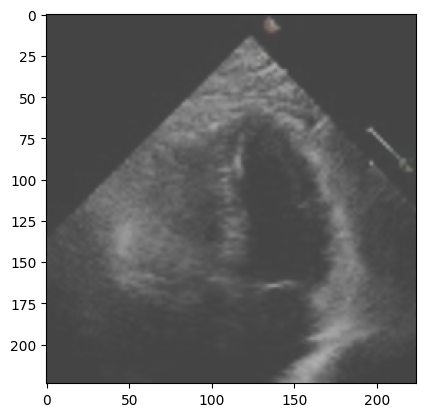

In [14]:
plt.imshow(dataset[-100]['pixel_values'][0].permute(1, 2, 0).sigmoid().numpy())

In [15]:
model = MAEPretrainer(cfg)

trainer = pl.Trainer(
    max_epochs=1,  # cfg['epochs'],
    precision=16,        # mixed precision for speed
    accelerator="auto",
    gradient_clip_val=1.0,
    accumulate_grad_batches=5,
)
trainer.fit(model, loader)  # 52810, 10030

/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/lightning_fabric/connector.py:572: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a

Epoch 0: 100%|██████████| 52810/52810 [1:30:48<00:00,  9.69it/s, v_num=2, train_loss=0.0245] 

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 52810/52810 [1:30:50<00:00,  9.69it/s, v_num=2, train_loss=0.0245]


In [16]:
model.model.save_pretrained('models/mae_pretrained_echonet')
torch.save(model.model.state_dict(), "models/mae_pretrained_echonet.pth")

In [17]:
def min_max_scale(x):
    return (x - x.min()) / (x.max() - x.min())

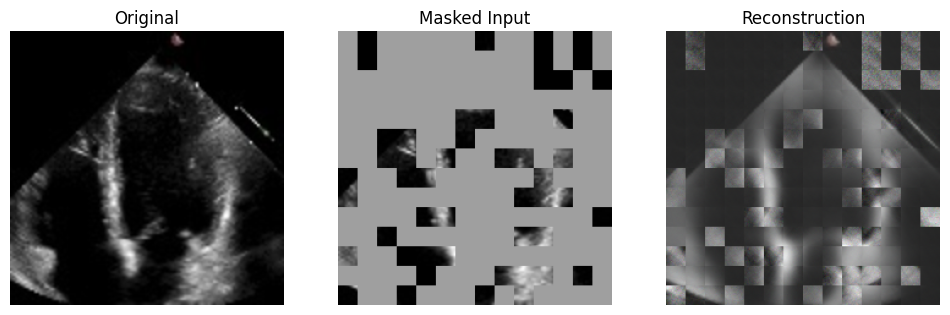

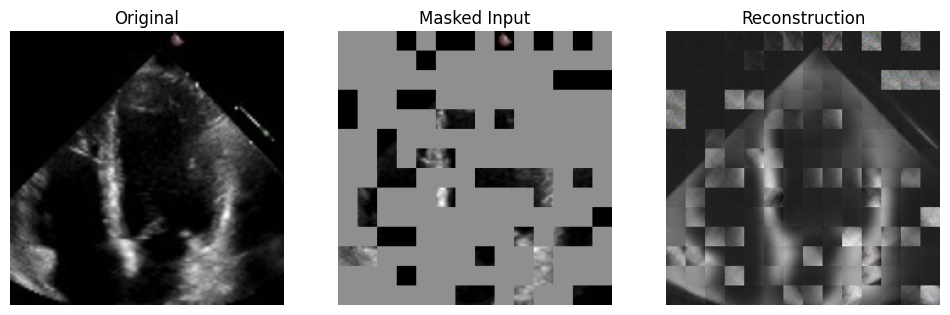

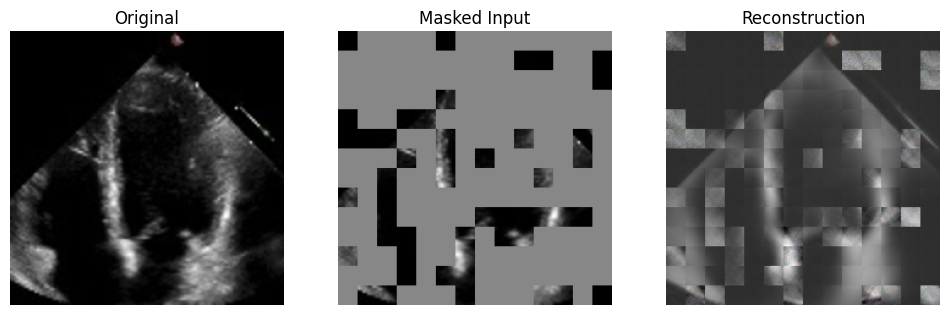

In [18]:
# test_paths = records[:3]
# ds = EchoPretrainDataset(test_paths, transform)  #   EchoEvalDataset
# dl = torch.utils.data.DataLoader(ds, batch_size=3)  # 

# 1. Run one batch
with torch.no_grad():
    model.eval()
    batch = next(iter(loader))  # dict or tensor: shape (B,1,224,224)
    outputs = model(batch)  # ViTMAEForPreTraining or your MAE model
    logits = outputs.logits        # (B, N, patch_dim)
    mask = outputs.mask.to(torch.bool)       # (B, N)  True = masked
    originals = batch['pixel_values']                # (B,1,H,W)

# 2. Unpatchify to images
#    Assuming your MAE model has patchify/unpatchify methods
reconstructed = model.model.unpatchify(logits.cpu())      # (B,1,H,W)
patched = model.model.patchify(originals.cpu())           # (B,N,patch_dim)
# Zero out masked patches
patched[mask] = 0
masked_inputs = model.model.unpatchify(patched)           # (B,1,H,W)

# 3. Convert to CPU numpy arrays & transpose to HxWxC
def to_numpy(img_tensor):
    # img_tensor: (1,H,W) or (H,W)
    arr = img_tensor.squeeze().cpu().numpy()  # (H,W)
    if cfg['num_channels'] == 3:
        arr = arr.transpose(1, 2, 0)
    return arr

# 4. Plot side by side
B = originals.shape[0]
for i in range(min(B, 3)):
    inp = min_max_scale(to_numpy(originals[i]))
    msk = min_max_scale(to_numpy(masked_inputs[i]))
    rec = min_max_scale(to_numpy(reconstructed[i]))

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(inp, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(msk, cmap='gray'); axes[1].set_title("Masked Input")
    axes[2].imshow(rec, cmap='gray'); axes[2].set_title("Reconstruction")
    for ax in axes:
        ax.axis('off')
    plt.show()

In [19]:
def unpatchify_with_original_visible(logits, pixel_values, mask, patch_size=16, channels=3):
    """
    logits: MAE output → shape (B, N, patch_dim)
    pixel_values: original images → (B, 3, 224, 224)
    mask: boolean mask → (B, N), True = masked
    Returns: reconstructed image (B, 3, 224, 224)
    """
    B, N, D = logits.shape
    assert D == patch_size * patch_size * channels, "Patch dim mismatch"

    # Step 1: patchify original images
    def patchify(imgs):
        B, C, H, W = imgs.shape
        h = w = H // patch_size
        patches = imgs.reshape(B, C, h, patch_size, w, patch_size)
        patches = patches.permute(0, 2, 4, 3, 5, 1)  # (B, h, w, p, p, C)
        patches = patches.reshape(B, h * w, patch_size * patch_size * C)
        return patches

    original_patches = patchify(pixel_values)

    # Step 2: replace unmasked patches in logits with original
    final_patches = logits.clone()
    final_patches[~mask] = original_patches[~mask]  # only unmasked get replaced

    # Step 3: unpatchify
    h = w = int(N ** 0.5)
    patches = final_patches.reshape(B, h, w, patch_size, patch_size, channels)
    patches = patches.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, p, w, p)
    imgs = patches.reshape(B, channels, h * patch_size, w * patch_size)
    return imgs

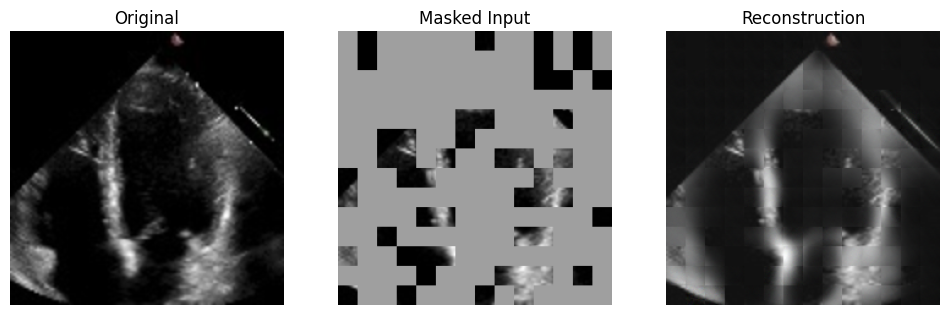

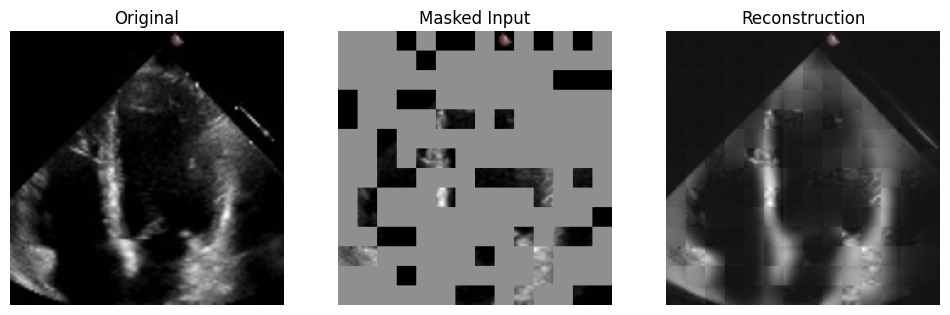

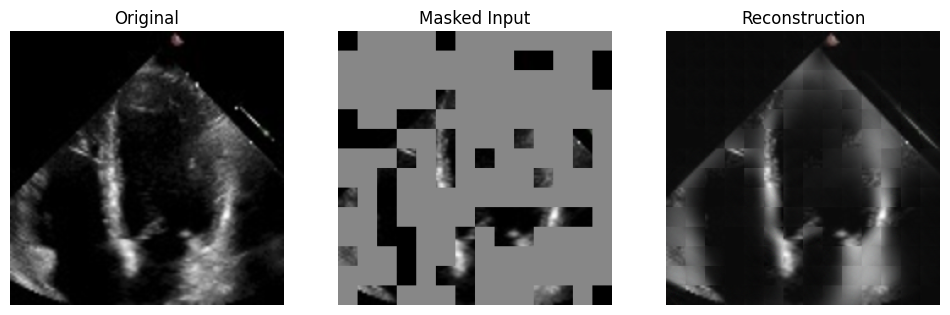

In [20]:
reconstructed = unpatchify_with_original_visible(
    logits=outputs.logits,
    pixel_values=batch["pixel_values"],
    mask=outputs.mask.to(torch.bool),
    patch_size=16,
    channels=3
)

B = originals.shape[0]
for i in range(min(B, 3)):
    inp = min_max_scale(to_numpy(originals[i]))
    msk = min_max_scale(to_numpy(masked_inputs[i]))
    rec = min_max_scale(to_numpy(reconstructed[i]))

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(inp, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(msk, cmap='gray'); axes[1].set_title("Masked Input")
    axes[2].imshow(rec, cmap='gray'); axes[2].set_title("Reconstruction")
    for ax in axes:
        ax.axis('off')
    plt.show()